## Visualizzazione risultati BRT

In [1]:
from pathlib import Path

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ---------------------------------------------------------------------
# Valori fissati per ottenere la slice 3D (x_rel, y_rel, theta_rel)
# ---------------------------------------------------------------------

V_H_FIXED = 6.0       # m/s
DELTA_E_FIXED = 0.0   # rad
V_E_FIXED = 6.0       # m/s

# ---------------------------------------------------------------------
# Individuazione automatica della root del progetto
# ---------------------------------------------------------------------

search_paths = [Path.cwd(), *Path.cwd().parents]

PROJECT_ROOT = next(
    (
        path
        for path in search_paths
        if (path / "results" / "brt").is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Cartella results/brt non trovata. "
        "Avvia il notebook dalla cartella del progetto o da examples."
    )

BRT_DIR = PROJECT_ROOT / "results" / "brt"

metric_paths = {
    "Euclidean": BRT_DIR / "euclidean.npz",
    "DCE": BRT_DIR / "dce.npz",
    "TTC": BRT_DIR / "ttc.npz",
    "eggert" : BRT_DIR / "eggert.npz",
    "rss": BRT_DIR / "rss.npz",
}

missing_files = [
    str(path)
    for path in metric_paths.values()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "File BRT mancanti:\n" + "\n".join(missing_files)
    )

# ---------------------------------------------------------------------
# Caricamento delle slice
# ---------------------------------------------------------------------

metric_data = {}

for metric_name, file_path in metric_paths.items():
    with np.load(file_path, allow_pickle=False) as data:
        x_rel = np.asarray(data["x_rel"])
        y_rel = np.asarray(data["y_rel"])
        theta_rel = np.asarray(data["theta_rel"])
        v_H = np.asarray(data["v_H"])
        delta_E = np.asarray(data["delta_E"])
        v_E = np.asarray(data["v_E"])

        i_v_H = int(np.argmin(np.abs(v_H - V_H_FIXED)))
        i_delta_E = int(np.argmin(np.abs(delta_E - DELTA_E_FIXED)))
        i_v_E = int(np.argmin(np.abs(v_E - V_E_FIXED)))

        V0_slice = np.asarray(
            data["V0"][:, :, :, i_v_H, i_delta_E, i_v_E],
            dtype=float,
        )

        BRT_slice = np.asarray(
            data["BRT"][:, :, :, i_v_H, i_delta_E, i_v_E],
            dtype=float,
        )

        metric_data[metric_name] = {
            "x_rel": x_rel,
            "y_rel": y_rel,
            "theta_rel": theta_rel,
            "V0": V0_slice,
            "BRT": BRT_slice,
            "v_H": float(v_H[i_v_H]),
            "delta_E": float(delta_E[i_delta_E]),
            "v_E": float(v_E[i_v_E]),
        }

        print(
            f"{metric_name:10s} | "
            f"v_H = {v_H[i_v_H]:.3f} m/s | "
            f"delta_E = {delta_E[i_delta_E]:.4f} rad | "
            f"v_E = {v_E[i_v_E]:.3f} m/s | "
            f"V0 range = [{V0_slice.min():.3f}, {V0_slice.max():.3f}] | "
            f"BRT range = [{BRT_slice.min():.3f}, {BRT_slice.max():.3f}]"
        )

Euclidean  | v_H = 5.286 m/s | delta_E = 0.0000 rad | v_E = 5.286 m/s | V0 range = [-3.422, 14.695] | BRT range = [-3.422, 13.844]
DCE        | v_H = 5.286 m/s | delta_E = 0.0000 rad | v_E = 5.286 m/s | V0 range = [-3.422, 13.974] | BRT range = [-3.513, 13.396]
TTC        | v_H = 5.286 m/s | delta_E = 0.0000 rad | v_E = 5.286 m/s | V0 range = [-3.000, 3.000] | BRT range = [-3.170, 3.000]
eggert     | v_H = 5.286 m/s | delta_E = 0.0000 rad | v_E = 5.286 m/s | V0 range = [-0.200, 0.800] | BRT range = [-0.208, 0.800]
rss        | v_H = 5.286 m/s | delta_E = 0.0000 rad | v_E = 5.286 m/s | V0 range = [-15.053, 8.760] | BRT range = [-16.915, 8.760]


## Visualizzazione 3D

In [5]:
import numpy as np
import plotly.graph_objects as go
from scipy.ndimage import gaussian_filter

# Metrica da visualizzare: "Euclidean", "DCE" oppure "TTC"
METRIC_NAME = "rss"

# Intensità dello smussamento, espressa in celle della griglia.
# 0.0: nessuno smussamento; 0.8: leggero; 1.5: più marcato.
SMOOTH_SIGMA = 1.0

current = metric_data[METRIC_NAME]

X, Y, THETA = np.meshgrid(
    current["x_rel"],
    current["y_rel"],
    current["theta_rel"],
    indexing="ij",
)

# Copie smussate esclusivamente per la visualizzazione.
# Ordine degli assi: x_rel, y_rel, theta_rel.
# "wrap" mantiene la periodicità di theta_rel.
# Forma della griglia tridimensionale.
# Indici delle coordinate da mantenere fisse.
# Modifica questi tre indici per scegliere una slice diversa.
I_V_H = 4       # Da 0 a 7
I_DELTA_E = 5   # Da 0 a 10
I_V_E = 4       # Da 0 a 7

def smooth_for_plot(values):
    values = np.asarray(values, dtype=float)

    # Estrazione della slice 3D: (x_rel, y_rel, theta_rel).
    if values.ndim == 6:
        values = values[
            :, :, :,
            I_V_H,
            I_DELTA_E,
            I_V_E,
        ]

    if values.shape != X.shape:
        raise ValueError(
            f"La slice ha forma {values.shape}, "
            f"ma la griglia XYZ ha forma {X.shape}."
        )

    return gaussian_filter(
        values,
        sigma=SMOOTH_SIGMA,
        mode=("nearest", "nearest", "wrap"),
    )

V0_plot = smooth_for_plot(current["V0"])
BRT_plot = smooth_for_plot(current["BRT"])

fig = go.Figure()

# Illuminazione morbida per evidenziare la curvatura.
lighting = dict(
    ambient=0.65,
    diffuse=0.8,
    specular=0.15,
    roughness=0.8,
    fresnel=0.1,
)

# V0 interno
fig.add_trace(
    go.Isosurface(
        x=X.ravel(),
        y=Y.ravel(),
        z=THETA.ravel(),
        value=V0_plot.ravel(),
        isomin=0.0,
        isomax=0.0,
        surface_count=1,
        colorscale=[[0.0, "#1f77b4"], [1.0, "#1f77b4"]],
        showscale=False,
        showlegend=True,
        opacity=0.85,
        caps=dict(x_show=False, y_show=False, z_show=False),
        lighting=lighting,
        lightposition=dict(x=100, y=150, z=200),
        name="V₀ = 0",
        hovertemplate=(
            "V₀ = 0 (smussato)<br>"
            "x_rel = %{x:.2f} m<br>"
            "y_rel = %{y:.2f} m<br>"
            "θ_rel = %{z:.3f} rad"
            "<extra></extra>"
        ),
    )
)

# BRT esterno
fig.add_trace(
    go.Isosurface(
        x=X.ravel(),
        y=Y.ravel(),
        z=THETA.ravel(),
        value=BRT_plot.ravel(),
        isomin=0.0,
        isomax=0.0,
        surface_count=1,
        colorscale=[[0.0, "#d62728"], [1.0, "#d62728"]],
        showscale=False,
        showlegend=True,
        opacity=0.15,
        caps=dict(x_show=False, y_show=False, z_show=False),
        lighting=lighting,
        lightposition=dict(x=100, y=150, z=200),
        name="BRT(-3 s) = 0",
        hovertemplate=(
            "BRT(-3 s) = 0 (smussato)<br>"
            "x_rel = %{x:.2f} m<br>"
            "y_rel = %{y:.2f} m<br>"
            "θ_rel = %{z:.3f} rad"
            "<extra></extra>"
        ),
    )
)

fig.update_layout(
    title=(
        f"{METRIC_NAME}: V₀ = 0 and BRT at t = -3 s"
        "<br><sup>"
        f"Slice indices: v_H = {I_V_H}, "
        f"δ_E = {I_DELTA_E}, "
        f"v_E = {I_V_E}"
        "</sup>"
    ),
    template="plotly_white",
    scene=dict(
        xaxis_title="x_rel [m]",
        yaxis_title="y_rel [m]",
        zaxis_title="θ_rel [rad]",
        aspectmode="manual",
        aspectratio=dict(x=1.5, y=1.0, z=0.8),
        camera=dict(eye=dict(x=1.55, y=1.55, z=1.15)),
    ),
    width=1000,
    height=750,
    margin=dict(l=10, r=10, b=10, t=100),
    legend=dict(
        orientation="h",
        x=0.5,
        xanchor="center",
        y=1.02,
        yanchor="bottom",
    ),
)

fig.show()

## Visualizzazione tabella con slice 2D

Figura salvata in: /home/alessio-grisorio/TESI/hj_reachability/results/figures/rss_V0_t0.png
Metrica: rss
Tempo visualizzato: 0.0 s
theta_rel richiesto/usato: 1.5708 / 1.5708 rad
delta_E richiesto/usato: 0.0000 / 0.0000 rad
Velocità ego usate: [2.4285714626312256, 5.285714626312256, 9.571429252624512] m/s
Velocità human usate: [2.4285714626312256, 5.285714626312256, 9.571429252624512] m/s
Colorbar: [-16.6440, 11.2866]


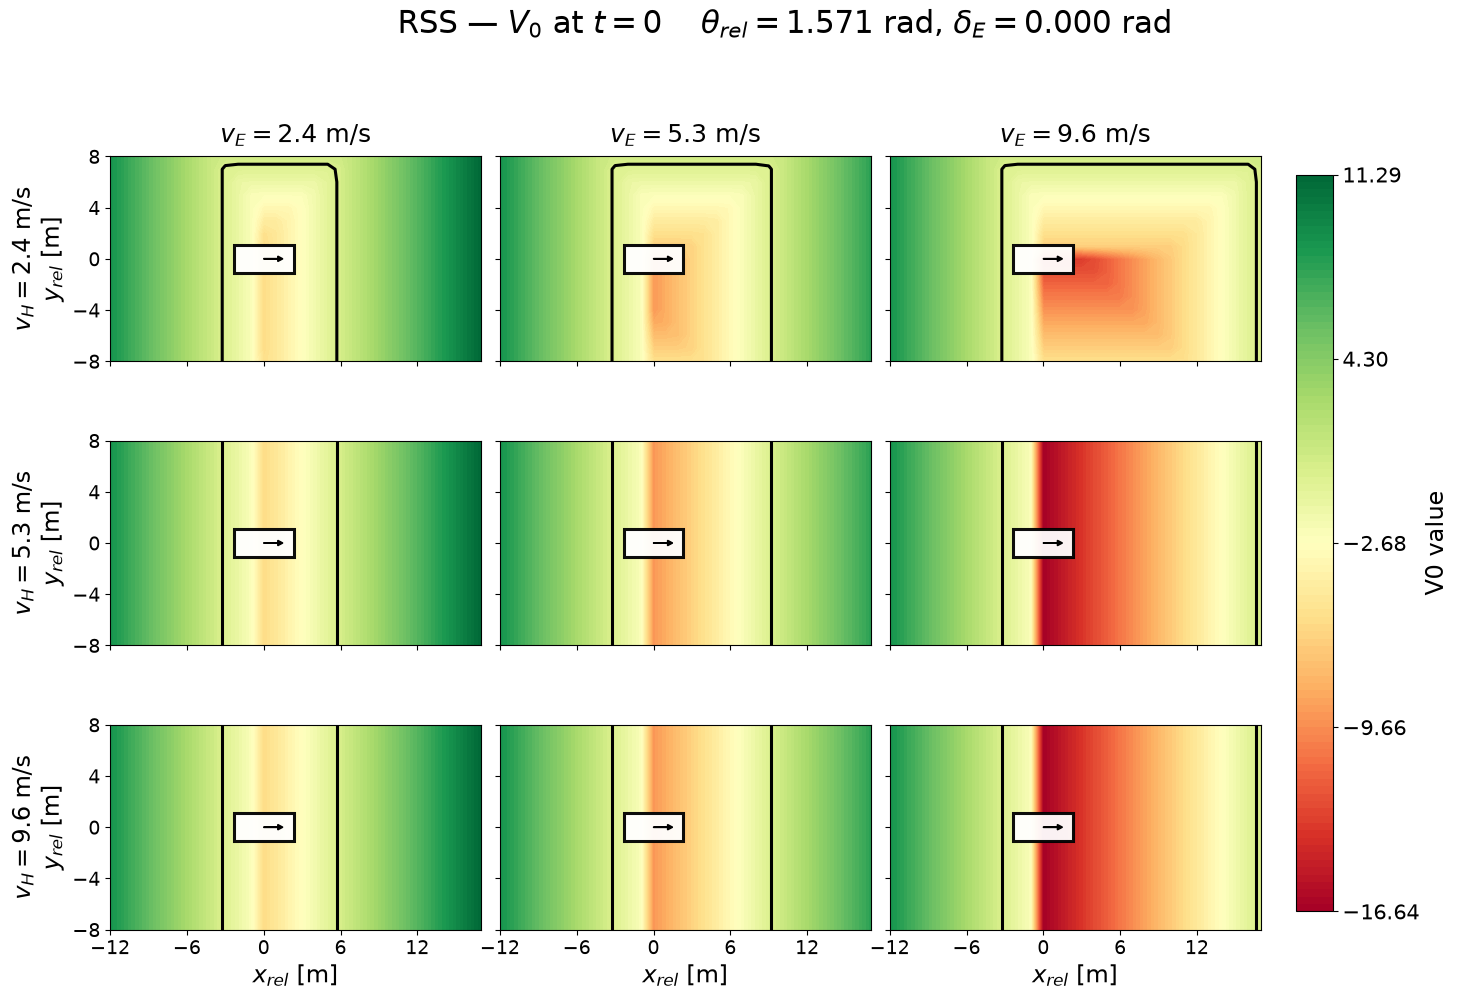

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator

# =====================================================================
# CONFIGURAZIONE MANUALE
# =====================================================================

METRIC_NAME = "rss"   # "euclidean", "dce" oppure "ttc"

EGO_SPEEDS = [3.0, 6.0, 9.0]       # v_E [m/s] -> colonne
HUMAN_SPEEDS = [3.0, 6.0, 9.0]     # v_H [m/s] -> righe

THETA_REL = np.pi/2       # [rad]
DELTA_E = 0.0         # [rad]

TIME = 0.0           # 0.0 per V0, -3.0 per BRT

SAVE_FIGURE = True
OUTPUT_FORMAT = "png"  # "png", "pdf" oppure "svg"
OUTPUT_DPI = 300

# Dimensioni dell'ego
EGO_LENGTH = 4.68  # [m]
EGO_WIDTH = 2.20   # [m]

# =====================================================================
# CONTROLLI
# =====================================================================

if len(EGO_SPEEDS) != 3 or len(HUMAN_SPEEDS) != 3:
    raise ValueError(
        "EGO_SPEEDS e HUMAN_SPEEDS devono contenere esattamente 3 valori."
    )

if not (np.isclose(TIME, 0.0) or np.isclose(TIME, -3.0)):
    raise ValueError("TIME deve essere 0.0 oppure -3.0.")

valid_metrics = {"euclidean", "dce", "ttc", "eggert", "rss"}

if METRIC_NAME.lower() not in valid_metrics:
    raise ValueError(
        f"Metrica non valida. Scegli tra {sorted(valid_metrics)}."
    )

METRIC_NAME = METRIC_NAME.lower()

# =====================================================================
# INDIVIDUAZIONE DEL PROGETTO E CARICAMENTO
# =====================================================================

search_paths = [Path.cwd(), *Path.cwd().parents]

PROJECT_ROOT = next(
    (
        path
        for path in search_paths
        if (path / "results" / "brt").is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError("Cartella results/brt non trovata.")

BRT_PATH = PROJECT_ROOT / "results" / "brt" / f"{METRIC_NAME}.npz"

if not BRT_PATH.exists():
    raise FileNotFoundError(f"File non trovato: {BRT_PATH}")

with np.load(BRT_PATH, allow_pickle=False) as data:
    x_rel = np.asarray(data["x_rel"], dtype=float)
    y_rel = np.asarray(data["y_rel"], dtype=float)
    theta_grid = np.asarray(data["theta_rel"], dtype=float)
    v_H_grid = np.asarray(data["v_H"], dtype=float)
    delta_grid = np.asarray(data["delta_E"], dtype=float)
    v_E_grid = np.asarray(data["v_E"], dtype=float)

    field_name = "V0" if np.isclose(TIME, 0.0) else "BRT"
    field = np.asarray(data[field_name], dtype=float)

    stored_target_time = (
        float(data["target_time"])
        if "target_time" in data.files
        else -3.0
    )

if field.ndim != 6:
    raise ValueError(
        f"{field_name} deve essere 6D, ma ha shape {field.shape}."
    )

if np.isclose(TIME, -3.0) and not np.isclose(TIME, stored_target_time):
    raise ValueError(
        f"Il BRT salvato corrisponde a t={stored_target_time:.2f} s, "
        f"non a t={TIME:.2f} s."
    )

# =====================================================================
# SELEZIONE DEI PUNTI DI GRIGLIA PIÙ VICINI
# =====================================================================

def nearest_index(axis, requested_value):
    return int(np.argmin(np.abs(axis - requested_value)))


i_theta = nearest_index(theta_grid, THETA_REL)
i_delta = nearest_index(delta_grid, DELTA_E)

theta_used = float(theta_grid[i_theta])
delta_used = float(delta_grid[i_delta])

ego_indices = [
    nearest_index(v_E_grid, speed)
    for speed in EGO_SPEEDS
]

human_indices = [
    nearest_index(v_H_grid, speed)
    for speed in HUMAN_SPEEDS
]

ego_speeds_used = [
    float(v_E_grid[index])
    for index in ego_indices
]

human_speeds_used = [
    float(v_H_grid[index])
    for index in human_indices
]

if len(set(ego_indices)) != 3:
    raise ValueError(
        "Almeno due velocità ego selezionano lo stesso punto di griglia."
    )

if len(set(human_indices)) != 3:
    raise ValueError(
        "Almeno due velocità human selezionano lo stesso punto di griglia."
    )

# =====================================================================
# ESTRAZIONE DELLE 9 SLICE E COLORBAR COMUNE
# =====================================================================

slices = []

for i_v_H in human_indices:
    current_row = []

    for i_v_E in ego_indices:
        current_slice = field[
            :,
            :,
            i_theta,
            i_v_H,
            i_delta,
            i_v_E,
        ]

        current_row.append(current_slice)

    slices.append(current_row)

displayed_values = np.concatenate(
    [
        current_slice.ravel()
        for row in slices
        for current_slice in row
    ]
)

finite_values = displayed_values[np.isfinite(displayed_values)]

if finite_values.size == 0:
    raise ValueError("Le slice selezionate non contengono valori finiti.")

color_min = float(np.min(finite_values))
color_max = float(np.max(finite_values))

if np.isclose(color_min, color_max):
    color_min -= 1e-6
    color_max += 1e-6

color_levels = np.linspace(color_min, color_max, 101)

X, Y = np.meshgrid(
    x_rel,
    y_rel,
    indexing="ij",
)

# =====================================================================
# FIGURA 3x3
# =====================================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(18, 11),
    sharex=True,
    sharey=True,
    gridspec_kw={
        "hspace": 0.02,
        "wspace": 0.05,
    },
)

last_contour = None

for row_index, human_speed in enumerate(human_speeds_used):
    for column_index, ego_speed in enumerate(ego_speeds_used):
        ax = axes[row_index, column_index]
        current_slice = slices[row_index][column_index]

        last_contour = ax.contourf(
            X,
            Y,
            current_slice,
            levels=color_levels,
            cmap="RdYlGn",
            vmin=color_min,
            vmax=color_max,
            extend="neither",
        )

        # Livello zero
        if (
            np.nanmin(current_slice) <= 0.0
            and np.nanmax(current_slice) >= 0.0
        ):
            ax.contour(
                X,
                Y,
                current_slice,
                levels=[0.0],
                colors="black",
                linewidths=2.2,
            )

        # Rettangolo dell'ego, centrato nell'origine
        ego_rectangle = Rectangle(
            (-EGO_LENGTH / 2.0, -EGO_WIDTH / 2.0),
            EGO_LENGTH,
            EGO_WIDTH,
            facecolor="white",
            edgecolor="black",
            linewidth=2.2,
            alpha=0.95,
            zorder=10,
        )

        ax.add_patch(ego_rectangle)

        # Freccia che indica la direzione longitudinale dell'ego
        ax.arrow(
            0.0,
            0.0,
            EGO_LENGTH * 0.32,
            0.0,
            width=0.045,
            head_width=0.42,
            head_length=0.40,
            color="black",
            length_includes_head=True,
            zorder=11,
        )

        ax.set_aspect("equal", adjustable="box")
        ax.tick_params(axis="both", labelsize=14)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

        if row_index == 0:
            ax.set_title(
                rf"$v_E={ego_speed:.1f}\ \mathrm{{m/s}}$",
                fontsize=18,
                pad=10,
            )

        if column_index == 0:
            ax.set_ylabel(
                rf"$v_H={human_speed:.1f}\ \mathrm{{m/s}}$"
                "\n"
                rf"$y_{{rel}}\ [\mathrm{{m}}]$",
                fontsize=17,
            )

        if row_index == 2:
            ax.set_xlabel(
                r"$x_{rel}\ [\mathrm{m}]$",
                fontsize=17,
            )

# =====================================================================
# COLORBAR E TITOLO
# =====================================================================

colorbar = fig.colorbar(
    last_contour,
    ax=axes,
    location="right",
    shrink=0.87,
    pad=0.025,
    ticks=np.linspace(color_min, color_max, 5),
)

colorbar.ax.tick_params(labelsize=15)
colorbar.set_label(
    f"{field_name} value",
    fontsize=17,
)

time_description = (
    r"$V_0$ at $t=0$"
    if np.isclose(TIME, 0.0)
    else rf"BRT at $t={stored_target_time:.1f}\ \mathrm{{s}}$"
)

fig.suptitle(
    (
        f"{METRIC_NAME.upper()} — {time_description}\t"
        rf"$\theta_{{rel}}={theta_used:.3f}\ \mathrm{{rad}}$, "
        rf"$\delta_E={delta_used:.3f}\ \mathrm{{rad}}$"
    ),
    fontsize=22,
)

# =====================================================================
# SALVATAGGIO
# =====================================================================

if SAVE_FIGURE:
    output_directory = PROJECT_ROOT / "results" / "figures"
    output_directory.mkdir(parents=True, exist_ok=True)

    time_tag = "t0" if np.isclose(TIME, 0.0) else "t_minus_3"

    output_path = (
        output_directory
        / f"{METRIC_NAME}_{field_name}_{time_tag}.{OUTPUT_FORMAT}"
    )

    fig.savefig(
        output_path,
        dpi=OUTPUT_DPI,
        bbox_inches="tight",
    )

    print(f"Figura salvata in: {output_path.resolve()}")

print(f"Metrica: {METRIC_NAME}")
print(f"Tempo visualizzato: {TIME:.1f} s")
print(f"theta_rel richiesto/usato: {THETA_REL:.4f} / {theta_used:.4f} rad")
print(f"delta_E richiesto/usato: {DELTA_E:.4f} / {delta_used:.4f} rad")
print(f"Velocità ego usate: {ego_speeds_used} m/s")
print(f"Velocità human usate: {human_speeds_used} m/s")
print(f"Colorbar: [{color_min:.4f}, {color_max:.4f}]")

plt.show()

## Confronto livello zero

Valori richiesti e valori effettivamente utilizzati:
v_E richiesta = 3.000 m/s -> usata = 2.429 m/s
v_E richiesta = 6.000 m/s -> usata = 5.286 m/s
v_E richiesta = 9.000 m/s -> usata = 9.571 m/s
v_H richiesta = 3.000 m/s -> usata = 2.429 m/s
v_H richiesta = 6.000 m/s -> usata = 5.286 m/s
v_H richiesta = 9.000 m/s -> usata = 9.571 m/s
theta_rel richiesto = 0.0000 rad -> usato = 0.0000 rad
delta_E richiesto = 0.0000 rad -> usato = 0.0000 rad

Figura salvata in: /home/alessio-grisorio/TESI/hj_reachability/results/figures/zero_level_metric_comparison_t0.png


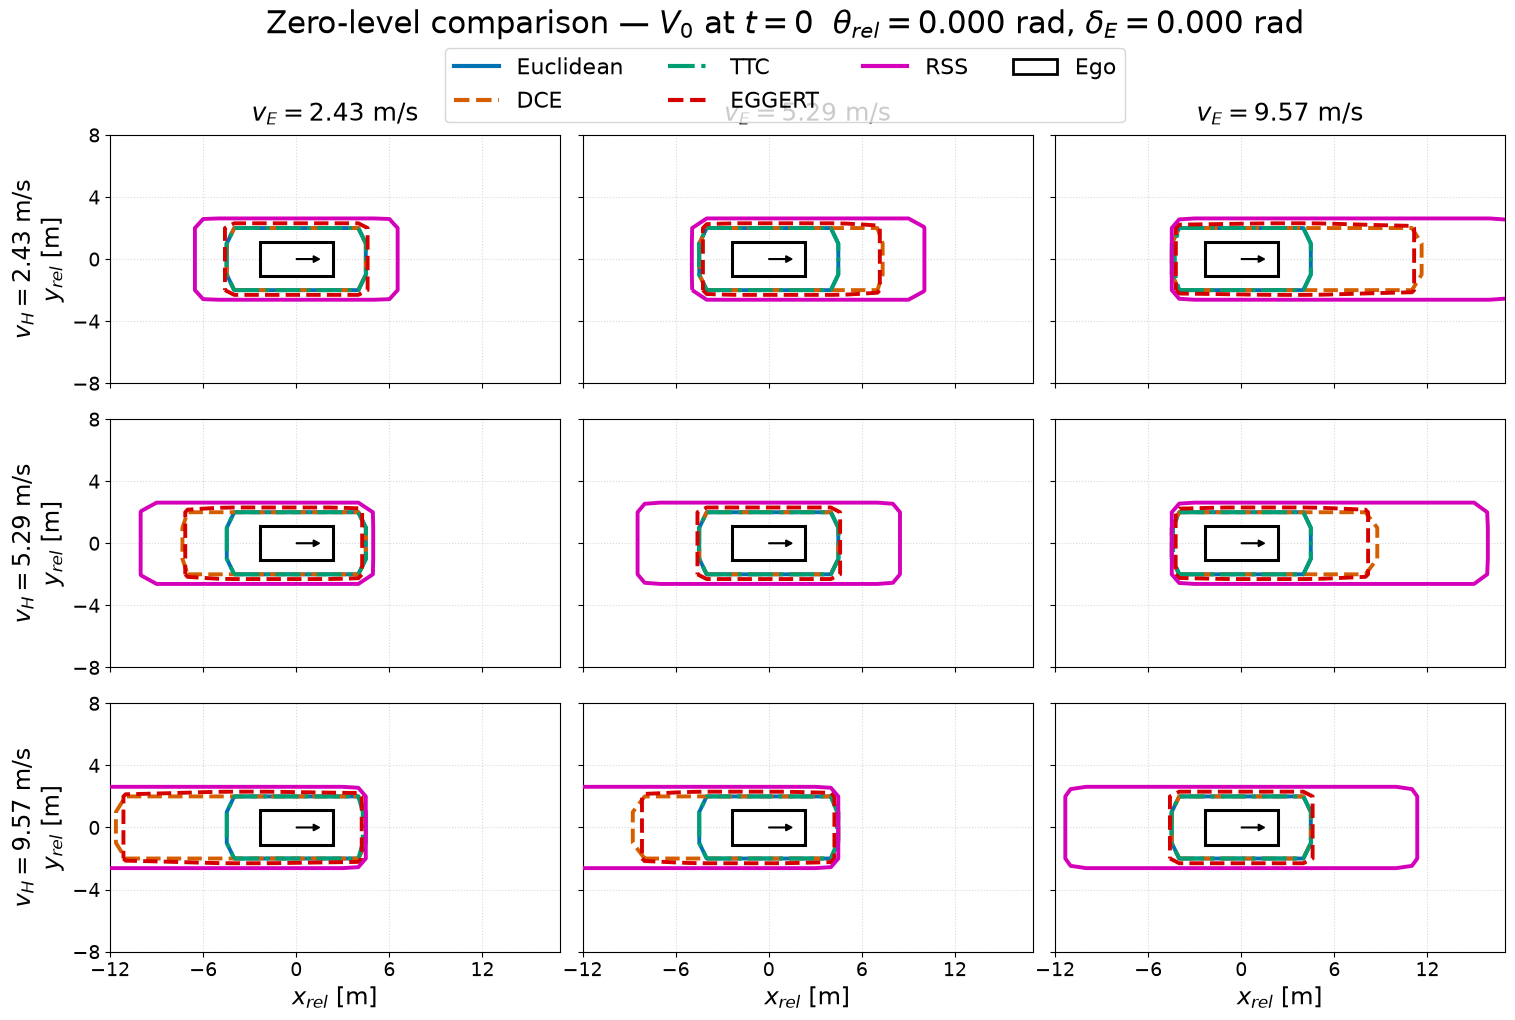

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from matplotlib.ticker import MaxNLocator

# =====================================================================
# CONFIGURAZIONE MANUALE
# =====================================================================

EGO_SPEEDS = [3.0, 6.0, 9.0]       # valori richiesti [m/s]
HUMAN_SPEEDS = [3.0, 6.0, 9.0]     # valori richiesti [m/s]

THETA_REL = 0.0       # valore richiesto [rad]
DELTA_E = 0.0         # valore richiesto [rad]

TIME = 0.0           # 0.0 per V0, -3.0 per BRT

SAVE_FIGURE = True
OUTPUT_FORMAT = "png"  # "png", "pdf" oppure "svg"
OUTPUT_DPI = 300

EGO_LENGTH = 4.68  # [m]
EGO_WIDTH = 2.20   # [m]

METRIC_STYLES = {
    "euclidean": {
        "label": "Euclidean",
        "color": "#0072B2",
        "linestyle": "-",
    },
    "dce": {
        "label": "DCE",
        "color": "#D55E00",
        "linestyle": "--",
    },
    "ttc": {
        "label": "TTC",
        "color": "#009E73",
        "linestyle": "-.",
    },
    "eggert": {
        "label": "EGGERT",
        "color": "#D50000",
        "linestyle": "--",
    },
    "rss": {
        "label": "RSS",
        "color": "#D500B9",
        "linestyle": "-", 
    }
}

# =====================================================================
# CONTROLLI
# =====================================================================

if len(EGO_SPEEDS) != 3 or len(HUMAN_SPEEDS) != 3:
    raise ValueError(
        "EGO_SPEEDS e HUMAN_SPEEDS devono contenere esattamente 3 valori."
    )

if not (np.isclose(TIME, 0.0) or np.isclose(TIME, -3.0)):
    raise ValueError("TIME deve essere 0.0 oppure -3.0.")

# =====================================================================
# INDIVIDUAZIONE DELLA ROOT DEL PROGETTO
# =====================================================================

search_paths = [Path.cwd(), *Path.cwd().parents]

PROJECT_ROOT = next(
    (
        path
        for path in search_paths
        if (path / "results" / "brt").is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError("Cartella results/brt non trovata.")

BRT_DIRECTORY = PROJECT_ROOT / "results" / "brt"

# =====================================================================
# FUNZIONI
# =====================================================================

def nearest_index(axis, requested_value):
    """Indice del punto di griglia più vicino al valore richiesto."""
    return int(np.argmin(np.abs(axis - requested_value)))


def load_metric(metric_name):
    """Carica il file NPZ relativo alla metrica."""
    file_path = BRT_DIRECTORY / f"{metric_name}.npz"

    if not file_path.exists():
        raise FileNotFoundError(f"File non trovato: {file_path}")

    with np.load(file_path, allow_pickle=False) as data:
        return {
            "x_rel": np.asarray(data["x_rel"], dtype=float),
            "y_rel": np.asarray(data["y_rel"], dtype=float),
            "theta_rel": np.asarray(data["theta_rel"], dtype=float),
            "v_H": np.asarray(data["v_H"], dtype=float),
            "delta_E": np.asarray(data["delta_E"], dtype=float),
            "v_E": np.asarray(data["v_E"], dtype=float),
            "V0": np.asarray(data["V0"], dtype=float),
            "BRT": np.asarray(data["BRT"], dtype=float),
            "target_time": (
                float(data["target_time"])
                if "target_time" in data.files
                else -3.0
            ),
        }


# =====================================================================
# CARICAMENTO DELLE TRE METRICHE
# =====================================================================

metric_data = {
    metric_name: load_metric(metric_name)
    for metric_name in METRIC_STYLES
}

field_name = "V0" if np.isclose(TIME, 0.0) else "BRT"

if np.isclose(TIME, -3.0):
    for metric_name, data in metric_data.items():
        if not np.isclose(data["target_time"], TIME):
            raise ValueError(
                f"{metric_name}: il BRT salvato corrisponde a "
                f"t={data['target_time']:.2f} s, non a t={TIME:.2f} s."
            )

# =====================================================================
# VERIFICA CHE LE TRE METRICHE USINO LA STESSA GRIGLIA
# =====================================================================

reference_data = metric_data["euclidean"]

axes_to_check = [
    "x_rel",
    "y_rel",
    "theta_rel",
    "v_H",
    "delta_E",
    "v_E",
]

for metric_name, data in metric_data.items():
    for axis_name in axes_to_check:
        reference_axis = reference_data[axis_name]
        current_axis = data[axis_name]

        if (
            reference_axis.shape != current_axis.shape
            or not np.allclose(reference_axis, current_axis)
        ):
            raise ValueError(
                f"La griglia di {metric_name} non coincide con quella "
                f"Euclidean lungo la dimensione '{axis_name}'."
            )

# =====================================================================
# VALORI EFFETTIVAMENTE UTILIZZATI
# =====================================================================

ego_indices = [
    nearest_index(reference_data["v_E"], requested_speed)
    for requested_speed in EGO_SPEEDS
]

human_indices = [
    nearest_index(reference_data["v_H"], requested_speed)
    for requested_speed in HUMAN_SPEEDS
]

i_theta = nearest_index(
    reference_data["theta_rel"],
    THETA_REL,
)

i_delta = nearest_index(
    reference_data["delta_E"],
    DELTA_E,
)

if len(set(ego_indices)) != 3:
    raise ValueError(
        "Almeno due velocità ego richieste selezionano "
        "lo stesso punto di griglia."
    )

if len(set(human_indices)) != 3:
    raise ValueError(
        "Almeno due velocità human richieste selezionano "
        "lo stesso punto di griglia."
    )

ego_speeds_used = [
    float(reference_data["v_E"][index])
    for index in ego_indices
]

human_speeds_used = [
    float(reference_data["v_H"][index])
    for index in human_indices
]

theta_used = float(
    reference_data["theta_rel"][i_theta]
)

delta_used = float(
    reference_data["delta_E"][i_delta]
)

print("Valori richiesti e valori effettivamente utilizzati:")

for requested, used in zip(EGO_SPEEDS, ego_speeds_used):
    print(
        f"v_E richiesta = {requested:.3f} m/s"
        f" -> usata = {used:.3f} m/s"
    )

for requested, used in zip(HUMAN_SPEEDS, human_speeds_used):
    print(
        f"v_H richiesta = {requested:.3f} m/s"
        f" -> usata = {used:.3f} m/s"
    )

print(
    f"theta_rel richiesto = {THETA_REL:.4f} rad"
    f" -> usato = {theta_used:.4f} rad"
)

print(
    f"delta_E richiesto = {DELTA_E:.4f} rad"
    f" -> usato = {delta_used:.4f} rad"
)

# =====================================================================
# FIGURA 3x3
# =====================================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(18, 11),
    sharex=True,
    sharey=True,
    gridspec_kw={
        "hspace": 0.02,
        "wspace": 0.05,
    },
)

X, Y = np.meshgrid(
    reference_data["x_rel"],
    reference_data["y_rel"],
    indexing="ij",
)

x_min = float(reference_data["x_rel"].min())
x_max = float(reference_data["x_rel"].max())
y_min = float(reference_data["y_rel"].min())
y_max = float(reference_data["y_rel"].max())

missing_contours = []

for row_index, i_v_H in enumerate(human_indices):
    for column_index, i_v_E in enumerate(ego_indices):
        ax = axes[row_index, column_index]

        # -------------------------------------------------------------
        # Livello zero delle tre metriche
        # -------------------------------------------------------------

        for metric_name, style in METRIC_STYLES.items():
            data = metric_data[metric_name]

            current_slice = data[field_name][
                :,
                :,
                i_theta,
                i_v_H,
                i_delta,
                i_v_E,
            ]

            finite_slice = current_slice[
                np.isfinite(current_slice)
            ]

            if finite_slice.size == 0:
                missing_contours.append(
                    (
                        metric_name,
                        human_speeds_used[row_index],
                        ego_speeds_used[column_index],
                        np.nan,
                        np.nan,
                    )
                )
                continue

            slice_min = float(np.min(finite_slice))
            slice_max = float(np.max(finite_slice))

            if slice_min <= 0.0 <= slice_max:
                ax.contour(
                    X,
                    Y,
                    current_slice,
                    levels=[0.0],
                    colors=[style["color"]],
                    linestyles=[style["linestyle"]],
                    linewidths=2.8,
                    zorder=5,
                )
            else:
                missing_contours.append(
                    (
                        metric_name,
                        human_speeds_used[row_index],
                        ego_speeds_used[column_index],
                        slice_min,
                        slice_max,
                    )
                )

        # -------------------------------------------------------------
        # Ego vehicle
        # -------------------------------------------------------------

        ego_rectangle = Rectangle(
            (-EGO_LENGTH / 2.0, -EGO_WIDTH / 2.0),
            EGO_LENGTH,
            EGO_WIDTH,
            facecolor="white",
            edgecolor="black",
            linewidth=2.2,
            alpha=1.0,
            zorder=10,
        )

        ax.add_patch(ego_rectangle)

        # Freccia orientata lungo l'asse longitudinale dell'ego
        ax.arrow(
            0.0,
            0.0,
            EGO_LENGTH * 0.32,
            0.0,
            width=0.045,
            head_width=0.42,
            head_length=0.40,
            color="black",
            length_includes_head=True,
            zorder=11,
        )

        # -------------------------------------------------------------
        # Formattazione subplot
        # -------------------------------------------------------------

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_aspect("equal", adjustable="box")

        ax.grid(
            visible=True,
            color="0.85",
            linewidth=0.8,
            linestyle=":",
            zorder=0,
        )

        ax.tick_params(
            axis="both",
            labelsize=14,
        )

        ax.xaxis.set_major_locator(
            MaxNLocator(nbins=5)
        )

        ax.yaxis.set_major_locator(
            MaxNLocator(nbins=5)
        )

        # Velocità ego effettivamente utilizzata
        if row_index == 0:
            ax.set_title(
                rf"$v_E={ego_speeds_used[column_index]:.2f}"
                rf"\ \mathrm{{m/s}}$",
                fontsize=18,
                pad=10,
            )

        # Velocità human effettivamente utilizzata
        if column_index == 0:
            ax.set_ylabel(
                rf"$v_H={human_speeds_used[row_index]:.2f}"
                rf"\ \mathrm{{m/s}}$"
                "\n"
                rf"$y_{{rel}}\ [\mathrm{{m}}]$",
                fontsize=17,
            )

        if row_index == 2:
            ax.set_xlabel(
                r"$x_{rel}\ [\mathrm{m}]$",
                fontsize=17,
            )

# =====================================================================
# LEGENDA
# =====================================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        color=style["color"],
        linestyle=style["linestyle"],
        linewidth=3.0,
        label=style["label"],
    )
    for style in METRIC_STYLES.values()
]

legend_handles.append(
    Patch(
        facecolor="white",
        edgecolor="black",
        linewidth=2.0,
        label="Ego",
    )
)

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.955),
    ncol=4,
    fontsize=16,
    frameon=True,
)

# =====================================================================
# TITOLO GENERALE
# =====================================================================

time_description = (
    r"$V_0$ at $t=0$"
    if np.isclose(TIME, 0.0)
    else rf"BRT at $t={TIME:.1f}\ \mathrm{{s}}$"
)

fig.suptitle(
    (
        f"Zero-level comparison — {time_description}\t"
        rf"$\theta_{{rel}}={theta_used:.3f}\ \mathrm{{rad}}$, "
        rf"$\delta_E={delta_used:.3f}\ \mathrm{{rad}}$"
    ),
    fontsize=22,
)

# =====================================================================
# SALVATAGGIO
# =====================================================================

if SAVE_FIGURE:
    output_directory = (
        PROJECT_ROOT
        / "results"
        / "figures"
    )

    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    time_tag = (
        "t0"
        if np.isclose(TIME, 0.0)
        else "t_minus_3"
    )

    output_path = (
        output_directory
        / (
            "zero_level_metric_comparison_"
            f"{time_tag}.{OUTPUT_FORMAT}"
        )
    )

    fig.savefig(
        output_path,
        dpi=OUTPUT_DPI,
        bbox_inches="tight",
    )

    print(f"\nFigura salvata in: {output_path.resolve()}")

# =====================================================================
# EVENTUALI LIVELLI ZERO MANCANTI
# =====================================================================

if missing_contours:
    print("\nLivello zero non presente nelle seguenti slice:")

    for (
        metric_name,
        human_speed,
        ego_speed,
        slice_min,
        slice_max,
    ) in missing_contours:
        print(
            f"{metric_name.upper():10s} | "
            f"v_H={human_speed:.2f} m/s | "
            f"v_E={ego_speed:.2f} m/s | "
            f"range=[{slice_min:.4f}, {slice_max:.4f}]"
        )

plt.show()